In [1]:
from rdkit import Chem
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, GridSearchCV, cross_val_score, cross_validate
import os
import glob
from scipy.stats import norm
import math
import random

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error 


T_0 = pd.read_excel('NTy2.xlsx')
T=np.array(T_0)
#from sklearn import preprocessing  LSD1FLy
#min_max_scaler = preprocessing.MinMaxScaler() 
#T=T_minMax = min_max_scaler.fit_transform(T)
#T=T.ravel()

print(T)  
print(len(T))

[[1]
 [1]
 [1]
 ...
 [0]
 [0]
 [0]]
3541


In [3]:
#读入特征    1000种描述符数据  LSD1FL1x.xlsx
X=pd.read_excel('CDK + Substructure + Substructure count.xlsx')
X=np.array(X) 
#min_max_scaler = preprocessing.MinMaxScaler() 
#X=X_minMax = min_max_scaler.fit_transform(X)
print(X)
print(len(X[0]))
print(len(X))

[[-1.03880000e+00  1.07910544e+00  2.97304000e+01 ...  0.00000000e+00
   0.00000000e+00  1.40000000e+01]
 [-5.33700000e-01  2.84835690e-01  3.77223000e+01 ...  0.00000000e+00
   0.00000000e+00  1.00000000e+01]
 [-6.70000000e-03  4.48900000e-05  4.29239000e+01 ...  0.00000000e+00
   0.00000000e+00  1.70000000e+01]
 ...
 [ 5.74600000e-01  3.30165160e-01  5.45012000e+01 ...  0.00000000e+00
   0.00000000e+00  1.70000000e+01]
 [ 4.81600000e-01  2.31938560e-01  4.41603000e+01 ...  0.00000000e+00
   0.00000000e+00  1.50000000e+01]
 [ 1.65400000e+00  2.73571600e+00  1.06514000e+02 ...  0.00000000e+00
   0.00000000e+00  1.20000000e+01]]
1718
3541


In [4]:
# 9 11  54 14 62

In [27]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.1,random_state=14)

In [28]:
#RT
import xgboost as xgb
clf = xgb.XGBClassifier(objective='binary:logistic',
    n_estimators=674,  
    learning_rate= 0.026914655988673278,  
    max_depth=13, 
    gamma=0.4113275489653747,  
    reg_alpha=0.46569149606232096,
    reg_lambda=0.8062070550550384, 
    subsample= 0.7427897957464792, 
    colsample_bytree=0.9236909498907971, 
    min_child_weight=1, 
    scale_pos_weight= 3.4981918567813044,
    tree_method='hist' )
clf.fit(X_train, T_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9236909498907971, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0.4113275489653747,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.026914655988673278,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=13, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=674, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [29]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
#from sklearn.externals import joblib
from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[133,  36],
       [ 22, 164]])

In [30]:
print (classification_report(T_test, T_pred , digits=3))

              precision    recall  f1-score   support

           0      0.858     0.787     0.821       169
           1      0.820     0.882     0.850       186

    accuracy                          0.837       355
   macro avg      0.839     0.834     0.835       355
weighted avg      0.838     0.837     0.836       355



In [31]:
f1=f1_score(T_test,T_pred,average='micro')
print("the f1 score: %.3f"%f1)

the f1 score: 0.837


<Figure size 1000x1000 with 0 Axes>

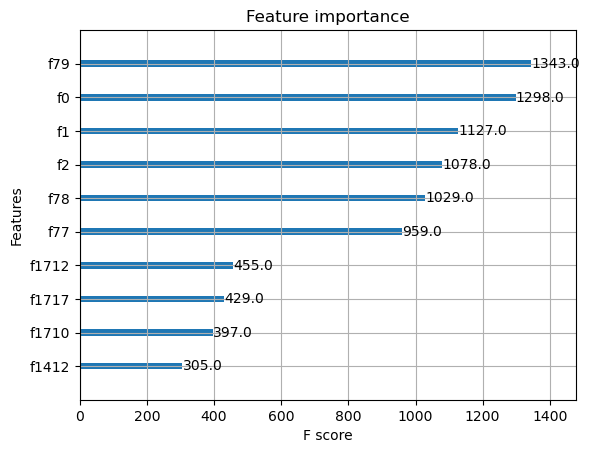

In [32]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
# 显示重要特征
fig = plt.figure(figsize=(10,10))
plot_importance(clf,max_num_features=10)
plt.show()

In [33]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[1594,    6],
       [   0, 1586]])

In [34]:
print (classification_report(T_train, T_pred , digits=3))

              precision    recall  f1-score   support

           0      1.000     0.996     0.998      1600
           1      0.996     1.000     0.998      1586

    accuracy                          0.998      3186
   macro avg      0.998     0.998     0.998      3186
weighted avg      0.998     0.998     0.998      3186



In [35]:
# 十倍交叉验证

In [36]:
from sklearn.model_selection import cross_validate

import xgboost as xgb
clf = xgb.XGBClassifier(objective='binary:logistic',
    n_estimators=674,  
    learning_rate= 0.026914655988673278,  
    max_depth=13, 
    gamma=0.4113275489653747,  
    reg_alpha=0.46569149606232096,
    reg_lambda=0.8062070550550384, 
    subsample= 0.7427897957464792, 
    colsample_bytree=0.9236909498907971, 
    min_child_weight=1, 
    scale_pos_weight= 3.4981918567813044,
    tree_method='hist' )
clf.fit(X_train, T_train)
cv = 10  # 十倍交叉验证的折数
scoring = ['accuracy', 'precision_macro', 'f1_macro']  # 评估指标


In [37]:
scores = cross_validate(clf, X_train, T_train, cv=cv, scoring=scoring, return_train_score=True)

mean_accuracy = scores['test_accuracy'].mean()
mean_precision = scores['test_precision_macro'].mean() 
mean_f1 = scores['test_f1_macro'].mean()

std_accuracy = scores['test_accuracy'].std()
std_precision = scores['test_precision_macro'].std()
std_f1 = scores['test_f1_macro'].std()

mean_train_accuracy = scores['train_accuracy'].mean()
mean_train_precision = scores['train_precision_macro'].mean()
mean_train_f1 = scores['train_f1_macro'].mean()

std_train_accuracy = scores['train_accuracy'].std()
std_train_precision = scores['train_precision_macro'].std()
std_train_f1 = scores['train_f1_macro'].std()

print(f'Mean Accuracy (Test): {mean_accuracy:.3f} ± {std_accuracy:.3f}')
print(f'Mean Precision (Test): {mean_precision:.3f} ± {std_precision:.3f}')
print(f'Mean F1 Score (Test): {mean_f1:.3f} ± {std_f1:.3f}')

print(f'Mean Accuracy (Train): {mean_train_accuracy:.3f} ± {std_train_accuracy:.3f}')
print(f'Mean Precision (Train): {mean_train_precision:.3f} ± {std_train_precision:.3f}')
print(f'Mean F1 Score (Train): {mean_train_f1:.3f} ± {std_train_f1:.3f}')


Mean Accuracy (Test): 0.836 ± 0.021
Mean Precision (Test): 0.836 ± 0.021
Mean F1 Score (Test): 0.836 ± 0.021
Mean Accuracy (Train): 0.998 ± 0.000
Mean Precision (Train): 0.998 ± 0.000
Mean F1 Score (Train): 0.998 ± 0.000


In [18]:
import pandas as pd

# 读入预测数据
Z = pd.read_excel('203.xlsx')

# 对齐训练用的列，缺的列补 0
Z = Z.reindex(columns=train_columns, fill_value=0)

# 转换成 numpy 或者直接喂给模型
Z_predict = clf.predict(Z)

print(Z_predict)


NameError: name 'train_columns' is not defined

In [27]:
#读入特征    描述符数据 
Z=pd.read_excel('203.xlsx')
Z=np.array(Z)
from sklearn import preprocessing  
#min_max_scaler = preprocessing.MinMaxScaler() 
#Z=Z_minMax = min_max_scaler.fit_transform(Z)
print(Z)
print(len(Z[0]))
print(len(Z))

[[-1.78370000e+00  3.18158569e+00  5.96297000e+01 ...  0.00000000e+00
   0.00000000e+00  6.00000000e+00]
 [-2.01340000e+00  4.05377956e+00  8.64160000e+00 ...  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [-1.77230000e+00  3.14104729e+00  4.94103000e+01 ...  0.00000000e+00
   0.00000000e+00  8.00000000e+00]
 ...
 [-5.01100000e-01  2.51101210e-01  4.17165000e+01 ...  0.00000000e+00
   0.00000000e+00  6.00000000e+00]
 [ 5.94000000e-02  3.52836000e-03  9.70264000e+01 ...  0.00000000e+00
   0.00000000e+00  1.30000000e+01]
 [-2.97740000e+00  8.86491076e+00  6.90004000e+01 ...  0.00000000e+00
   0.00000000e+00  8.00000000e+00]]
1718
203


In [28]:
Z_predict = clf.predict(Z)
print(Z_predict)

[1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1
 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1
 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1]


In [29]:
Z_predict = clf.predict(Z)
df=pd.DataFrame(Z_predict)
df.to_csv("1.csv",index=False,header=False)

In [30]:
Z_predict = clf.predict_proba(Z)
print(Z_predict)

[[0.17029583 0.82970417]
 [0.08024842 0.9197516 ]
 [0.21694416 0.78305584]
 [0.32964605 0.67035395]
 [0.24147874 0.75852126]
 [0.04002416 0.95997584]
 [0.47049665 0.52950335]
 [0.36953878 0.6304612 ]
 [0.57542443 0.42457557]
 [0.44392383 0.55607617]
 [0.7226758  0.2773242 ]
 [0.46749544 0.53250456]
 [0.24837828 0.7516217 ]
 [0.1947943  0.8052057 ]
 [0.31367618 0.6863238 ]
 [0.44171977 0.5582802 ]
 [0.36285138 0.6371486 ]
 [0.36629927 0.6337007 ]
 [0.29540277 0.70459723]
 [0.567521   0.432479  ]
 [0.4713819  0.5286181 ]
 [0.36972165 0.63027835]
 [0.5650728  0.4349272 ]
 [0.43069094 0.56930906]
 [0.5027518  0.49724814]
 [0.26856005 0.73143995]
 [0.36828917 0.6317108 ]
 [0.46100992 0.5389901 ]
 [0.27852708 0.7214729 ]
 [0.23966885 0.76033115]
 [0.25271213 0.74728787]
 [0.39942616 0.60057384]
 [0.13244158 0.8675584 ]
 [0.7203213  0.2796787 ]
 [0.23131216 0.76868784]
 [0.19680029 0.8031997 ]
 [0.15074801 0.849252  ]
 [0.16303694 0.83696306]
 [0.15587258 0.8441274 ]
 [0.18028665 0.81971335]


In [31]:
Z_predict = clf.predict_proba(Z)
df=pd.DataFrame(Z_predict)
df.to_csv("2.csv",index=False,header=False)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,f1_score
import lightgbm as lgbm

clf=lgbm.LGBMClassifier(boosting_type='gbdt',colsample_bytree=0.8,feature_fraction=0.8,bagging_fraction=0.4,num_leaves=10,min_child_samples=60,max_depth=-1,
                        learning_rate=0.05,n_estimators=500, n_jobs=1)
clf.fit(X_train,T_train)

In [153]:
import xgboost as xgb
clf = xgb.XGBClassifier(objective='binary:logistic',
    n_estimators=300,  # 增加树的数量以配合较小的学习率
    learning_rate=0.1,  # 尝试更小的学习率
    max_depth=5,  # 稍微增加树深度以捕捉更复杂的模式
    gamma=0.2,  # 添加gamma参数防止过拟合
    reg_alpha=0.01,  # 添加L1正则化
    reg_lambda=1.5,  # 添加L2正则化
    subsample=0.8,  # 添加子采样防止过拟合
    colsample_bytree=0.8,  # 添加特征子采样防止过拟合
    min_child_weight=3,  # 增加叶子节点最小权重和防止过拟合
    scale_pos_weight=1,  # 根据类别不平衡情况调整
    tree_method='hist')
clf.fit(X_train,T_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
#随机划分

In [189]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.1,random_state=14)

In [190]:
from sklearn.svm import SVC  # Support Vector Classifier
clf = SVC(kernel='linear') # 线性核函数
clf.fit(X_train,T_train)
SVC(C=1.0, cache_size=2000, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='linear', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

/PUBLIC/zyh/anaconda3/lib/python3.7/site-packages/sklearn/utils/validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1.0, cache_size=2000, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [316]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='liblinear',multi_class='ovr', C = 5, verbose = 100, max_iter=800)
clf.fit(X_train, T_train)

/export/home/zhaoyh/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LibLinear]iter  1 act 3.250e+03 pre 2.879e+03 delta 6.398e-01 f 8.366e+03 |g| 6.167e+04 CG   5
cg reaches trust region boundary
iter  2 act 1.350e+03 pre 1.229e+03 delta 8.558e-01 f 5.116e+03 |g| 1.135e+04 CG   5
cg reaches trust region boundary
iter  3 act 9.683e+02 pre 8.638e+02 delta 1.207e+00 f 3.766e+03 |g| 5.548e+03 CG   6
cg reaches trust region boundary
iter  4 act 7.273e+02 pre 6.318e+02 delta 1.598e+00 f 2.798e+03 |g| 2.187e+03 CG   6
cg reaches trust region boundary
iter  5 act 5.917e+02 pre 5.423e+02 delta 1.941e+00 f 2.071e+03 |g| 2.318e+03 CG   8
cg reaches trust region boundary
iter  6 act 4.594e+02 pre 3.998e+02 delta 2.469e+00 f 1.479e+03 |g| 1.572e+03 CG  11
cg reaches trust region boundary
iter  7 act 3.338e+02 pre 2.801e+02 delta 3.156e+00 f 1.020e+03 |g| 1.068e+03 CG  12
cg reaches trust region boundary
iter  8 act 2.330e+02 pre 1.922e+02 delta 4.058e+00 f 6.859e+02 |g| 5.114e+02 CG  15
iter  9 act 1.252e+02 pre 1.049e+02 delta 4.695e+00 f 4.529e+02 |g| 7.123e+02 

LogisticRegression(C=5, max_iter=800, multi_class='ovr', solver='liblinear',
                   verbose=100)

In [270]:
from sklearn.metrics import accuracy_score,precision_score,f1_score
import lightgbm as lgbm

clf=lgbm.LGBMClassifier(boosting_type='gbdt',colsample_bytree=0.8,feature_fraction=0.8,bagging_fraction=0.8,num_leaves=31,min_child_samples=60,max_depth=-1,
                        learning_rate=0.05,n_estimators=500, n_jobs=1)
clf.fit(X_train,T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8


LGBMClassifier(bagging_fraction=0.8, colsample_bytree=0.8, feature_fraction=0.8,
               learning_rate=0.05, min_child_samples=60, n_estimators=500,
               n_jobs=1)

In [466]:
import xgboost as xgb
clf = xgb.XGBClassifier(objective='binary:logistic',
    n_estimators=290,  
    learning_rate=0.1,  
    max_depth=5, 
    gamma=0.2,  
    reg_alpha=0.01,
    reg_lambda=1.5, 
    subsample=0.7, 
    colsample_bytree=0.8, 
    min_child_weight=3, 
    scale_pos_weight=1,
    tree_method='hist' )
clf.fit(X_train, T_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=290, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [467]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[368,  18],
       [ 23, 195]])

In [468]:
precision_score(T_test, T_pred,average='micro')
recall_score(T_test, T_pred,average='micro')
f1_score(T_test, T_pred,average='micro')

0.9321192052980133

In [469]:
print (classification_report(T_test, T_pred , digits=3))

              precision    recall  f1-score   support

           0      0.941     0.953     0.947       386
           1      0.915     0.894     0.905       218

    accuracy                          0.932       604
   macro avg      0.928     0.924     0.926       604
weighted avg      0.932     0.932     0.932       604



In [470]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[1534,    8],
       [   9,  863]])

In [461]:
print (classification_report(T_train, T_pred , digits=3))

              precision    recall  f1-score   support

           0      0.994     0.995     0.994      1542
           1      0.991     0.990     0.990       872

    accuracy                          0.993      2414
   macro avg      0.992     0.992     0.992      2414
weighted avg      0.993     0.993     0.993      2414



In [471]:
from sklearn.model_selection import cross_validate

clf = xgb.XGBClassifier(objective='binary:logistic',
    n_estimators=290,  # 增加树的数量以配合较小的学习率
    learning_rate=0.1,  # 尝试更小的学习率
    max_depth=5,  # 稍微增加树深度以捕捉更复杂的模式
    gamma=0.2,  # 添加gamma参数防止过拟合
    reg_alpha=0.01,  # 添加L1正则化
    reg_lambda=1.5,  # 添加L2正则化
    subsample=0.8,  # 添加子采样防止过拟合
    colsample_bytree=0.8,  # 添加特征子采样防止过拟合
    min_child_weight=3,  # 增加叶子节点最小权重和防止过拟合
    scale_pos_weight=1,  # 根据类别不平衡情况调整
    tree_method='hist')

cv = 10  # 十倍交叉验证的折数
scoring = ['accuracy', 'precision_macro', 'f1_macro']  # 评估指标

In [472]:
scores = cross_validate(clf, X_train, T_train, cv=cv, scoring=scoring, return_train_score=True)

mean_accuracy = scores['test_accuracy'].mean()
mean_precision = scores['test_precision_macro'].mean()
mean_f1 = scores['test_f1_macro'].mean()

std_accuracy = scores['test_accuracy'].std()
std_precision = scores['test_precision_macro'].std()
std_f1 = scores['test_f1_macro'].std()

mean_train_accuracy = scores['train_accuracy'].mean()
mean_train_precision = scores['train_precision_macro'].mean()
mean_train_f1 = scores['train_f1_macro'].mean()

std_train_accuracy = scores['train_accuracy'].std()
std_train_precision = scores['train_precision_macro'].std()
std_train_f1 = scores['train_f1_macro'].std()

print(f'Mean Accuracy (Test): {mean_accuracy:.3f} ± {std_accuracy:.3f}')
print(f'Mean Precision (Test): {mean_precision:.3f} ± {std_precision:.3f}')
print(f'Mean F1 Score (Test): {mean_f1:.3f} ± {std_f1:.3f}')

print(f'Mean Accuracy (Train): {mean_train_accuracy:.3f} ± {std_train_accuracy:.3f}')
print(f'Mean Precision (Train): {mean_train_precision:.3f} ± {std_train_precision:.3f}')
print(f'Mean F1 Score (Train): {mean_train_f1:.3f} ± {std_train_f1:.3f}')


Mean Accuracy (Test): 0.904 ± 0.023
Mean Precision (Test): 0.900 ± 0.025
Mean F1 Score (Test): 0.894 ± 0.026
Mean Accuracy (Train): 0.994 ± 0.001
Mean Precision (Train): 0.994 ± 0.001
Mean F1 Score (Train): 0.994 ± 0.001


In [131]:
y_pred_test=clf.predict(X_test)
df=pd.DataFrame(y_pred_test)
df.to_csv("./resulttestPLQYPreFENLEI.csv",index=False,header=False)
y_true=T_test
df=pd.DataFrame(y_true)
df.to_csv("./resulttestPLQYTrueFENLEI.csv",index=False,header=False)

In [322]:
import sklearn.neural_network as sk_nn
clf = sk_nn.MLPClassifier(activation='relu',solver='adam',alpha=1,learning_rate='adaptive',learning_rate_init=0.001,max_iter=800)
clf.fit(X_train,T_train)


/export/home/zhaoyh/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1109: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(alpha=1, learning_rate='adaptive', max_iter=800)

In [323]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[1507,   35],
       [  18,  854]])

In [324]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[347,  39],
       [ 17, 201]])

In [325]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.9533    0.8990    0.9253       386
           1     0.8375    0.9220    0.8777       218

    accuracy                         0.9073       604
   macro avg     0.8954    0.9105    0.9015       604
weighted avg     0.9115    0.9073    0.9082       604



In [60]:
import sklearn.neighbors as sk_neighbors
clf = sk_neighbors.KNeighborsClassifier(n_neighbors=3) 
clf.fit(X_train,T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=2)

In [ ]:
3 (28)

In [187]:
T_predict = clf.predict_proba(X_test)
print(T_predict)

[[0.89120114 0.10879886]
 [0.712852   0.28714803]
 [0.95991486 0.04008513]
 [0.86178946 0.1382105 ]
 [0.05650443 0.9434956 ]
 [0.9233618  0.07663825]
 [0.901219   0.09878097]
 [0.08180124 0.91819876]
 [0.93511415 0.06488586]
 [0.8108375  0.1891625 ]
 [0.9720138  0.02798625]
 [0.11866879 0.8813312 ]
 [0.79600525 0.20399477]
 [0.18039101 0.819609  ]
 [0.00493914 0.99506086]
 [0.7044027  0.29559729]
 [0.75206274 0.24793726]
 [0.9364985  0.06350145]
 [0.98495364 0.01504633]
 [0.9315744  0.0684256 ]
 [0.13153559 0.8684644 ]
 [0.1445896  0.8554104 ]
 [0.03740722 0.9625928 ]
 [0.14178938 0.8582106 ]
 [0.05166537 0.94833463]
 [0.20506465 0.79493535]
 [0.09188968 0.9081103 ]
 [0.922427   0.07757299]
 [0.57833326 0.42166674]
 [0.5334028  0.46659717]
 [0.06868792 0.9313121 ]
 [0.12314516 0.87685484]
 [0.96036804 0.03963193]
 [0.7671742  0.23282582]
 [0.91811264 0.08188737]
 [0.78241396 0.21758601]
 [0.89488155 0.10511846]
 [0.8337362  0.16626382]
 [0.1753776  0.8246224 ]
 [0.15668225 0.84331775]


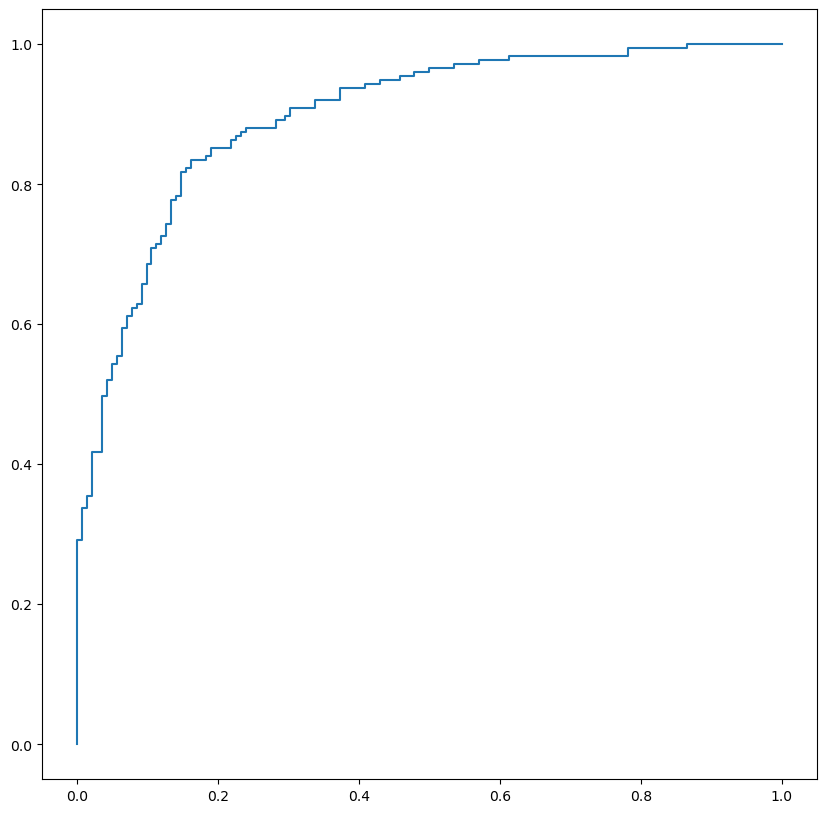

In [188]:
from sklearn.metrics import roc_curve

fpr, tpr, thres = roc_curve(T_test.astype(int), T_predict[:,1])

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,10))

plt.plot(fpr, tpr)

plt.show()

In [189]:
from sklearn.metrics import roc_auc_score

score = roc_auc_score(T_test, T_predict[:,1])
print (score)

0.8971830985915492


In [326]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier (
bootstrap=True, max_depth=None,
max_features='auto', max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=1, min_samples_split=10,
min_weight_fraction_leaf=0.0, n_estimators=300, n_jobs=2,
oob_score=False, random_state=725, verbose=0, warm_start=False)
clf.fit(X_train,T_train) # 使用训练集训练模型
T_pre = clf.predict(X_test) # 使用模型对测试集进行预测

/tmp/ipykernel_139470/987808909.py:9: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X_train,T_train) # 使用训练集训练模型


In [19]:
from sklearn.tree import DecisionTreeClassifier
 
clf = DecisionTreeClassifier(                         splitter="best",
                         max_depth=None,
                         min_samples_split=20,
                         min_samples_leaf=10,
                         min_weight_fraction_leaf=0.0,
                         max_features=0.5,
                         random_state=2,
                         max_leaf_nodes=None,
                         min_impurity_decrease=0)
 # 所以参数均置为默认状态
clf.fit(X_train,T_train) # 使用训练集训练模型
T_pre = clf.predict(X_test) # 使用模型对测试集进行预测

ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

In [331]:
from sklearn.metrics import accuracy_score
 
print (accuracy_score(T_pre, T_test))

0.8245033112582781


In [335]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[343,  43],
       [ 31, 187]])

In [336]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.9171    0.8886    0.9026       386
           1     0.8130    0.8578    0.8348       218

    accuracy                         0.8775       604
   macro avg     0.8651    0.8732    0.8687       604
weighted avg     0.8796    0.8775    0.8782       604



In [81]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train,T_train)

/PUBLIC/apps/anaconda2/envs/py3/lib/python3.7/site-packages/sklearn/utils/validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [334]:
from sklearn.svm import SVC  # Support Vector Classifier
clf = SVC(kernel='linear') # 线性核函数
clf.fit(X_train,T_train)
SVC(C=10.0, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='linear', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

/export/home/zhaoyh/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=10.0, gamma='auto_deprecated', kernel='linear')